# Mutações
### Imports

In [2]:
from random import randint, choices, sample, uniform, seed
import numpy as np
import cupy as cp
import cupyx.scipy.ndimage as scimg
import cupyx.scipy.signal as scicon
import math
import imageio.v3 as imio
from PIL import Image, ImageFile, ImageOps
import cv2

import classes.pokedex as pokedex
import classes.mutation as mutation
import classes.utils as utils


%matplotlib inline 
from matplotlib import pyplot as plt


### Gets

In [3]:

pkd = pokedex.Pokedex(target_dex='809', score_type='rgba')
mut = mutation.Mutation()

9
rgba
<class 'cupy.ndarray'>


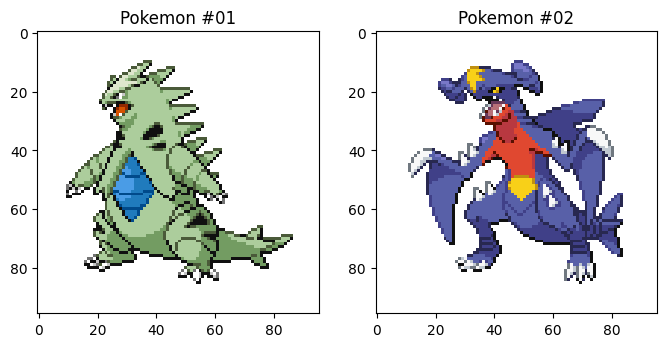

In [4]:
pk1 = pkd.load_pokepng('248')

pk2 = pkd.load_pokepng('445')

figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('Pokemon #01')
axis[0].imshow(cp.asnumpy(pk1), interpolation='nearest')
axis[1].set_title('Pokemon #02')
axis[1].imshow(cp.asnumpy(pk2), interpolation='nearest')


plt.show()



## Testes

### Rotações

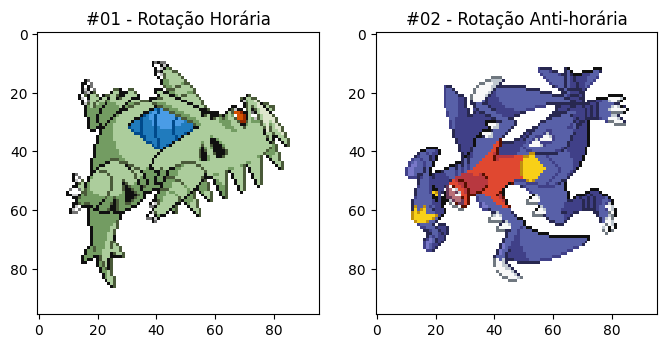

In [5]:
pk_mut1 = cp.rot90(pk1, k=-1)
pk_mut2 = cp.rot90(pk2, k=1)

figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Rotação Horária')
axis[0].imshow(cp.asnumpy(pk_mut1), interpolation='nearest')
axis[1].set_title('#02 - Rotação Anti-horária')
axis[1].imshow(cp.asnumpy(pk_mut2), interpolation='nearest')


plt.show()

### Espelhamento

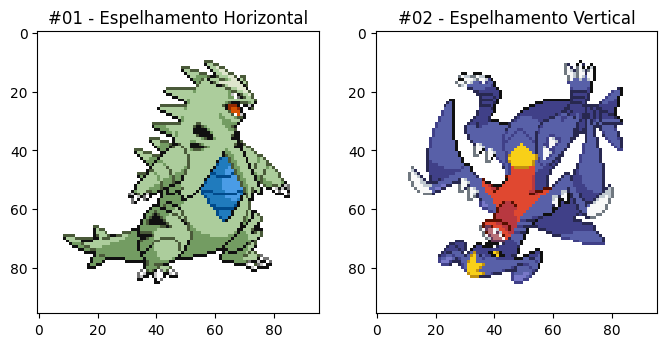

In [6]:
pk_mut1 = cp.fliplr(pk1)
pk_mut2 = cp.flipud(pk2)

figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Espelhamento Horizontal')
axis[0].imshow(cp.asnumpy(pk_mut1), interpolation='nearest')
axis[1].set_title('#02 - Espelhamento Vertical')
axis[1].imshow(cp.asnumpy(pk_mut2), interpolation='nearest')


plt.show()

### Espelhamento Divisório

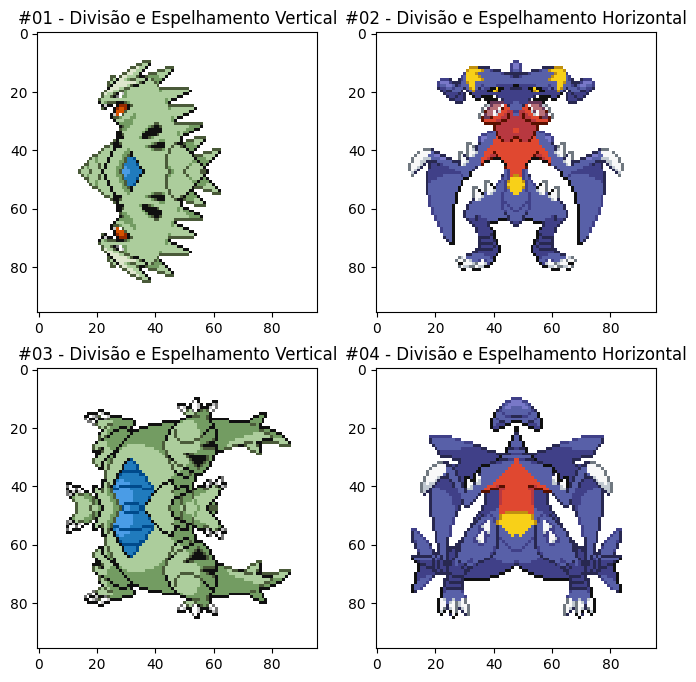

In [7]:
v_half = pk1.shape[0] // 2
pk_mut1a = cp.vstack((pk1[:v_half], cp.flipud(pk1[:v_half])))
pk_mut1b = cp.vstack((cp.flipud(pk1[v_half:]), pk1[v_half:]))
    
h_half = pk2.shape[1] // 2
pk_mut2a = cp.hstack((pk2[:, :h_half], cp.fliplr(pk2[:, :h_half])))
pk_mut2b = cp.hstack((cp.fliplr(pk2[:, h_half:]), pk2[:, h_half:]))
    
    
figure, axis = plt.subplots(2, 2, figsize=(8, 8))
axis[0,0].set_title('#01 - Divisão e Espelhamento Vertical')
axis[0,0].imshow(cp.asnumpy(pk_mut1a), interpolation='nearest')
axis[0,1].set_title('#02 - Divisão e Espelhamento Horizontal')
axis[0,1].imshow(cp.asnumpy(pk_mut2a), interpolation='nearest')
axis[1,0].set_title('#03 - Divisão e Espelhamento Vertical')
axis[1,0].imshow(cp.asnumpy(pk_mut1b), interpolation='nearest')
axis[1,1].set_title('#04 - Divisão e Espelhamento Horizontal')
axis[1,1].imshow(cp.asnumpy(pk_mut2b), interpolation='nearest')


plt.show()

## Conversões
### Preto e Branco

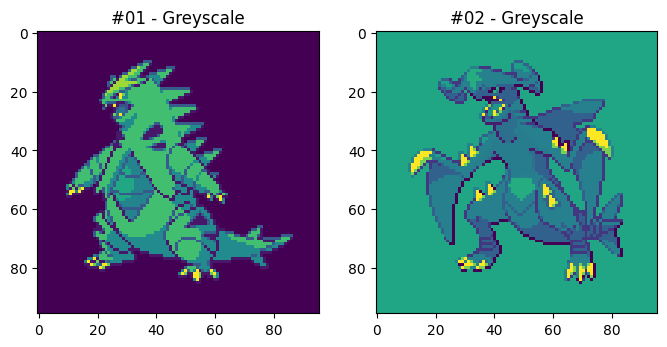

In [8]:
pk_mut1 = cp.mean(pk1[:,:,:3], axis=2)
pk_mut2 = cp.mean(pk2[:,:,:3], axis=2)

figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Greyscale')
axis[0].imshow(cp.asnumpy(pk_mut1), interpolation='nearest')
axis[1].set_title('#02 - Greyscale')
axis[1].imshow(cp.asnumpy(pk_mut2), interpolation='nearest')

### Threshold/Binario

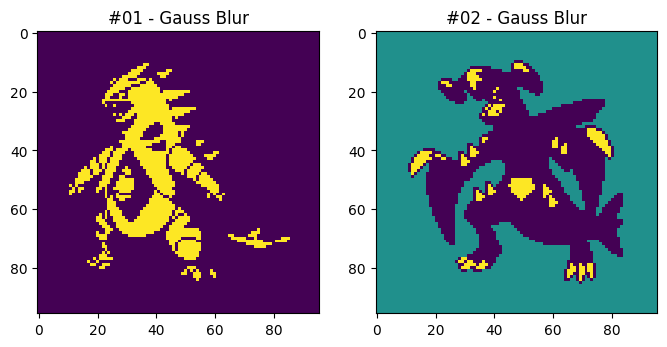

In [9]:
pk_mut1 = cp.mean(pk1[:,:,:3], axis=2)
pk_mut2 = cp.mean(pk2[:,:,:3], axis=2)

pk_mut1[pk_mut1[:,:] < 128] = 0
pk_mut1[pk_mut1[:,:] >= 128] = 255

pk_mut2[pk_mut2[:,:] < 128] = 0
pk_mut2[pk_mut2[:,:] >= 128] = 255
mk = pk2[:,:,3] == 0
pk_mut2[mk] = 128

figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Gauss Blur')
axis[0].imshow(cp.asnumpy(pk_mut1), interpolation='nearest')
axis[1].set_title('#02 - Gauss Blur')
axis[1].imshow(cp.asnumpy(pk_mut2), interpolation='nearest')

### Para RGBA

In [10]:
pk_mut1a = cp.mean(pk1[:,:,:3], axis=2)
pk_mut2a = cp.mean(pk2[:,:,:3], axis=2)

pk_mut1a[pk_mut1a[:,:] < 128] = 0
pk_mut1a[pk_mut1a[:,:] >= 128] = 255

pk_mut2a[pk_mut2a[:,:] < 128] = 0
pk_mut2a[pk_mut2a[:,:] >= 128] = 255

pk_mut1 = cp.zeros((pk1.shape[0],pk1.shape[1],4))
pk_mut1[:,:,2] = pk_mut1[:,:,1] = pk_mut1[:,:, 0] = pk_mut1a[:,:]
pk_mut1[:,:,3] = 255
pk_mut2[:,:,2] = pk_mut2[:,:,1] = pk_mut2[:,:, 0] = pk_mut2a[:,:]
pk_mut2[:,:,3] = 255

figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Para RGBA')
axis[0].imshow(cp.asnumpy(pk_mut1), interpolation='nearest')
axis[1].set_title('#02 - Para RGBA')
axis[1].imshow(cp.asnumpy(pk_mut2), interpolation='nearest')

IndexError: too many indices for array: array is 2-dimensional, but 3 were indexed

### Posterizar

In [ ]:
pk_mut1a = cp.copy(pk1)
pk_mut1a[:,:,:3] = cp.multiply(cp.round(cp.divide(pk1[:,:,:3],85)),85)
pk_mut2a = cp.copy(pk2)
pk_mut2a[:,:,:3] = cp.multiply(cp.round(cp.divide(pk2[:,:,:3],85)),85)

pk_mut1b = cp.copy(pk1)
pk_mut1b[:,:,:3] = cp.multiply(cp.floor(cp.divide(pk1[:,:,:3],37)),37)
pk_mut2b = cp.copy(pk2)
pk_mut2b[:,:,:3] = cp.multiply(cp.floor(cp.divide(pk2[:,:,:3],37)),37)

pk_mut1c = cp.copy(pk1)
pk_mut1c[:,:,:3] = cp.multiply(cp.round(cp.divide(pk1[:,:,:3],255)),255)
pk_mut2c = cp.copy(pk2)
pk_mut2c[:,:,:3] = cp.multiply(cp.round(cp.divide(pk2[:,:,:3],255)),255)

figure, axis = plt.subplots(2, 4, figsize=(16, 8))
axis[0,0].set_title('#01 - Original')
axis[0,0].imshow(cp.asnumpy(pk1), interpolation='nearest')
axis[0,1].set_title('#02 - Posterizado: 8cpc')
axis[0,1].imshow(cp.asnumpy(pk_mut1b), interpolation='nearest')
axis[0,2].set_title('#03 - Posterizado: 4cpc')
axis[0,2].imshow(cp.asnumpy(pk_mut1a), interpolation='nearest')
axis[0,3].set_title('#04 - Posterizado: 2cpc')
axis[0,3].imshow(cp.asnumpy(pk_mut1c), interpolation='nearest')

axis[1,0].set_title('#05 - Original')
axis[1,0].imshow(cp.asnumpy(pk2), interpolation='nearest')
axis[1,1].set_title('#06 - Posterizado: 8cpc')
axis[1,1].imshow(cp.asnumpy(pk_mut2b), interpolation='nearest')
axis[1,2].set_title('#07 - Posterizado: 4cpc')
axis[1,2].imshow(cp.asnumpy(pk_mut2a), interpolation='nearest')
axis[1,3].set_title('#08 - Posterizado: 2cpc')
axis[1,3].imshow(cp.asnumpy(pk_mut2c), interpolation='nearest')

### Monocromatico

In [ ]:
buncha_zeros = cp.zeros((pk1.shape[0],pk1.shape[1]))

pk_mut1a = cp.copy(pk1)
pk_mut1a[:,:,1] = pk_mut1a[:,:,0] = buncha_zeros
pk_mut2a = cp.copy(pk2)
pk_mut2a[:,:,1] = pk_mut2a[:,:,0] = buncha_zeros

pk_mut1b = cp.copy(pk1)
pk_mut1b[:,:,2] = pk_mut1b[:,:,0] = buncha_zeros
pk_mut2b = cp.copy(pk2)
pk_mut2b[:,:,2] = pk_mut2b[:,:,0] = buncha_zeros

pk_mut1c = cp.copy(pk1)
pk_mut1c[:,:,1] = pk_mut1c[:,:,2] = buncha_zeros
pk_mut2c = cp.copy(pk2)
pk_mut2c[:,:,1] = pk_mut2c[:,:,2] = buncha_zeros

pk_mut1d = cp.copy(pk1)
pk_mut1d[:,:,0] = buncha_zeros
pk_mut2d = cp.copy(pk2)
pk_mut2d[:,:,0] = buncha_zeros

pk_mut1e = cp.copy(pk1)
pk_mut1e[:,:,1] = buncha_zeros
pk_mut2e = cp.copy(pk2)
pk_mut2e[:,:,1] = buncha_zeros

pk_mut1f = cp.copy(pk1)
pk_mut1f[:,:,2] = buncha_zeros
pk_mut2f = cp.copy(pk2)
pk_mut2f[:,:,2] = buncha_zeros

figure, axis = plt.subplots(2, 7, figsize=(28, 8))
axis[0,0].set_title('#01 - Original')
axis[0,0].imshow(cp.asnumpy(pk1), interpolation='nearest')
axis[0,1].set_title('#02 - Monocroma: Azul')
axis[0,1].imshow(cp.asnumpy(pk_mut1a), interpolation='nearest')
axis[0,2].set_title('#03 - Monocroma: Verde')
axis[0,2].imshow(cp.asnumpy(pk_mut1b), interpolation='nearest')
axis[0,3].set_title('#04 - Monocroma: Vermelho')
axis[0,3].imshow(cp.asnumpy(pk_mut1c), interpolation='nearest')
axis[0,4].set_title('#05 - Bicroma: Ciano')
axis[0,4].imshow(cp.asnumpy(pk_mut1d), interpolation='nearest')
axis[0,5].set_title('#06 - Bicroma: Magenta')
axis[0,5].imshow(cp.asnumpy(pk_mut1e), interpolation='nearest')
axis[0,6].set_title('#07 - Bicroma: Amarelo')
axis[0,6].imshow(cp.asnumpy(pk_mut1f), interpolation='nearest')

axis[1,0].set_title('#08 - Original')
axis[1,0].imshow(cp.asnumpy(pk2), interpolation='nearest')
axis[1,1].set_title('#09 - Monocroma: Azul')
axis[1,1].imshow(cp.asnumpy(pk_mut2a), interpolation='nearest')
axis[1,2].set_title('#10 - Monocroma: Verde')
axis[1,2].imshow(cp.asnumpy(pk_mut2b), interpolation='nearest')
axis[1,3].set_title('#11 - Monocroma: Vermelho')
axis[1,3].imshow(cp.asnumpy(pk_mut2c), interpolation='nearest')
axis[1,4].set_title('#12 - Bicroma: Ciano')
axis[1,4].imshow(cp.asnumpy(pk_mut2d), interpolation='nearest')
axis[1,5].set_title('#13 - Bicroma: Magenta')
axis[1,5].imshow(cp.asnumpy(pk_mut2e), interpolation='nearest')
axis[1,6].set_title('#14 - Bicroma: Amarelo')
axis[1,6].imshow(cp.asnumpy(pk_mut2f), interpolation='nearest')

## Filtros
### Gaussian Blur

In [ ]:
pk_mut1 = cp.copy(pk1)
pk_mut1[:,:,0:3] = scimg.gaussian_filter(pk1[:,:,:3], sigma=1)
pk_mut2 = cp.copy(pk2)
pk_mut2[:,:,0:3] = scimg.gaussian_filter(pk2[:,:,:3], sigma=1)
#mk = pk2[:,:,3] > 0
#pk_mut2[mk,3] = 255

figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Gauss Blur')
axis[0].imshow(cp.asnumpy(pk_mut1), interpolation='nearest')
axis[1].set_title('#02 - Gauss Blur')
axis[1].imshow(cp.asnumpy(pk_mut2), interpolation='nearest')

### Box Blur

In [ ]:
kernel = cp.zeros((3,3,1))
kernel[:,:,0] = cp.array([
    [1.0, 1.0, 1.0],
    [1.0, 1.0, 1.0],
    [1.0, 1.0, 1.0],
])/9.0

pk_mut1 = scimg.convolve(pk1, kernel)
pk_mut2 = scimg.convolve(pk2, kernel)
mk = pk2[:,:,3] > 0
pk_mut2[mk,3] = 255


figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Box Blur')
axis[0].imshow(cp.asnumpy(pk_mut1), interpolation='nearest')
axis[1].set_title('#02 - Box Blur')
axis[1].imshow(cp.asnumpy(pk_mut2), interpolation='nearest')

### Mediana

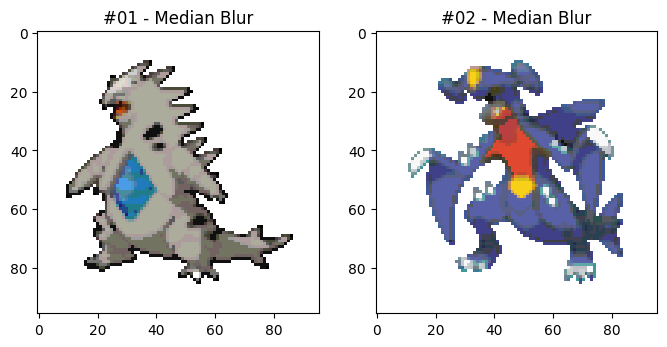

In [11]:
pk_mut1 = cp.copy(pk1)
pk_mut1[:,:,0:3] = scimg.median_filter(pk1[:,:,:3],size=3)


#pk_mut1 = scimg.convolve(pk1, weights=[])
#pk_mut1 = scicon.convolve2d()
pk_mut2 = cp.copy(pk2)
pk_mut2[:,:,0:3] = scimg.median_filter(pk2[:,:,:3], size=3)
#pk_mut2 = cv2.medianBlur(cp.asnumpy(pk2), 3)


figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Median Blur')
axis[0].imshow(cp.asnumpy(pk_mut1), interpolation='nearest')
axis[1].set_title('#02 - Median Blur')
axis[1].imshow(cp.asnumpy(pk_mut2), interpolation='nearest')

### Máximo/Mínimo

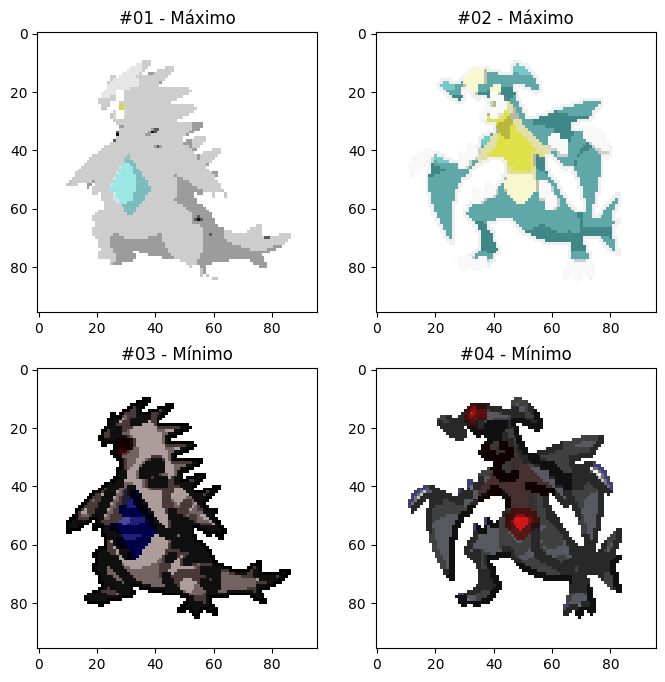

In [12]:
pk_mut1a = cp.copy(pk1)
pk_mut1a[:,:,0:3] = scimg.maximum_filter(pk1[:,:,:3],size=3)
pk_mut2a = cp.copy(pk2)
pk_mut2a[:,:,0:3] = scimg.maximum_filter(pk2[:,:,:3],size=3)

#pk_mut1 = scimg.convolve(pk1, weights=[])
#pk_mut1 = scicon.convolve2d()
pk_mut1b = cp.copy(pk1)
pk_mut1b[:,:,0:3] = scimg.minimum_filter(pk1[:,:,:3], size=3)
pk_mut2b = cp.copy(pk2)
pk_mut2b[:,:,0:3] = scimg.minimum_filter(pk2[:,:,:3], size=3)
#pk_mut2 = cv2.medianBlur(cp.asnumpy(pk2), 3)


figure, axis = plt.subplots(2, 2, figsize=(8,8))
axis[0,0].set_title('#01 - Máximo')
axis[0,0].imshow(cp.asnumpy(pk_mut1a), interpolation='nearest')
axis[0,1].set_title('#02 - Máximo')
axis[0,1].imshow(cp.asnumpy(pk_mut2a), interpolation='nearest')
axis[1,0].set_title('#03 - Mínimo')
axis[1,0].imshow(cp.asnumpy(pk_mut1b), interpolation='nearest')
axis[1,1].set_title('#04 - Mínimo')
axis[1,1].imshow(cp.asnumpy(pk_mut2b), interpolation='nearest')

### Sobel/Prewitt

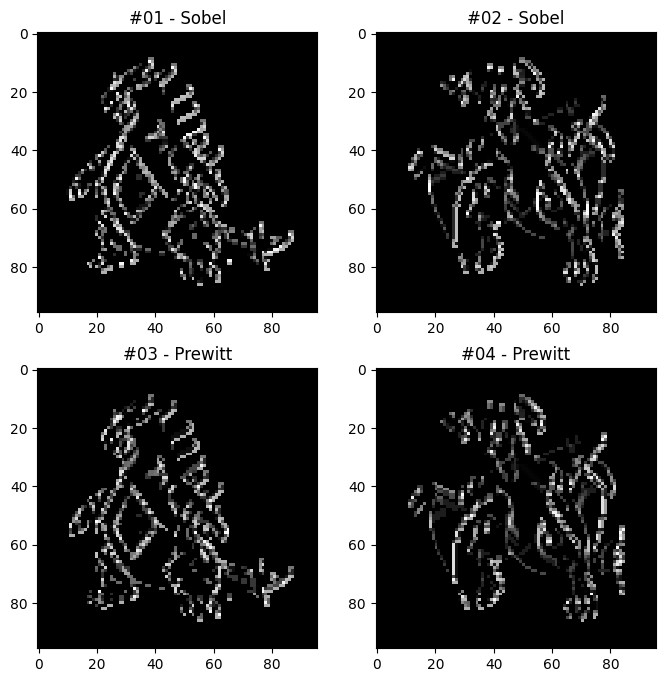

In [16]:
pk_mut1a = utils.to_rgba(scimg.sobel(utils.to_grayscale(cp.copy(pk1))))
#pk_mut2a = cp.copy(pk2)

#pk_mut2a = scimg.zoom(pk2, [4,4,1], mode='nearest', prefilter=False, order=0)
pk_mut2a = utils.to_rgba(scimg.sobel(utils.to_grayscale(cp.copy(pk2))))

pk_mut1b  = utils.to_rgba(scimg.prewitt(utils.to_grayscale(cp.copy(pk1))))
pk_mut2b = utils.to_rgba(scimg.prewitt(utils.to_grayscale(cp.copy(pk2))))


figure, axis = plt.subplots(2, 2, figsize=(8,8))
axis[0,0].set_title('#01 - Sobel')
axis[0,0].imshow(cp.asnumpy(pk_mut1a), interpolation='nearest')
axis[0,1].set_title('#02 - Sobel')
axis[0,1].imshow(cp.asnumpy(pk_mut2a), interpolation='nearest')
axis[1,0].set_title('#03 - Prewitt')
axis[1,0].imshow(cp.asnumpy(pk_mut1b), interpolation='nearest')
axis[1,1].set_title('#04 - Prewitt')
axis[1,1].imshow(cp.asnumpy(pk_mut2b), interpolation='nearest')

### Sharpen

In [ ]:
kernel = cp.zeros((3,3,1))
kernel[:,:,0] = cp.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0],
])
pk_mut1 = cp.copy(pk1)
pk_mut1[:,:,:3] = scimg.convolve(pk1[:,:,:3], kernel)
pk_mut2 = cp.copy(pk2)
pk_mut2[:,:,:3] = scimg.convolve(pk2[:,:,:3], kernel)


figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Sharpen')
axis[0].imshow(cp.asnumpy(pk_mut1), interpolation='nearest')
axis[1].set_title('#02 - Sharpen')
axis[1].imshow(cp.asnumpy(pk_mut2), interpolation='nearest')

### Bordas

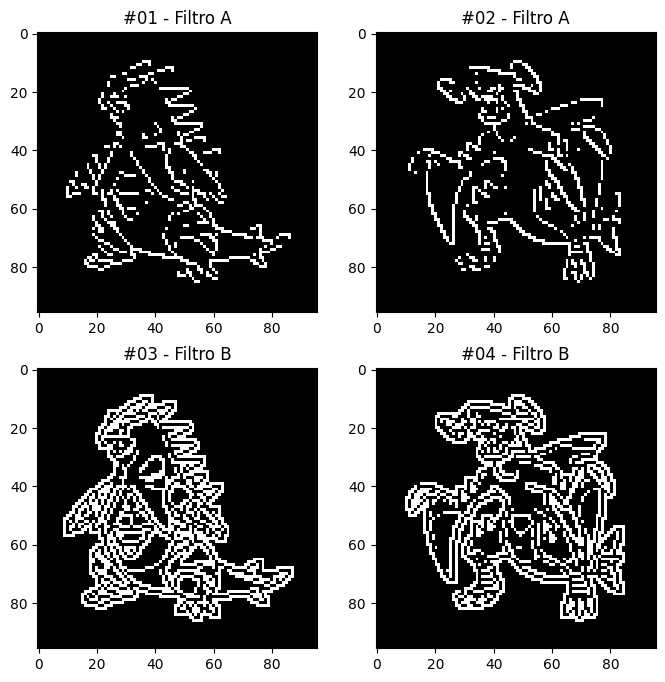

In [45]:
mk1 = pk1[:,:,3] == 255
mk2 = pk2[:,:,3] == 255

kernel = cp.zeros((3,3))
kernel[:,:] = cp.array([
    [0, 0, 1],
    [0, -2, 0],
    [1, 0, 0],
])

pk_mut1a =  scimg.convolve(utils.to_grayscale(pk1), kernel)
pk_mut2a = scimg.convolve(utils.to_grayscale(pk2), kernel)
kernel[:,:] = cp.array([
    [-1, -1, -1],
    [-1, 8, -1],
    [-1, -1, -1],
])
pk_mut1b =  scimg.convolve(utils.to_grayscale(pk1), kernel)
pk_mut2b = scimg.convolve(utils.to_grayscale(pk2), kernel)
ts = 64
pk_mut1a[pk_mut1a[:,:] >= ts] = 255
pk_mut1a[pk_mut1a[:,:] < ts] = 0
pk_mut1b[pk_mut1b[:,:] >= ts] = 255
pk_mut1b[pk_mut1b[:,:] < ts] = 0
pk_mut2a[pk_mut2a[:,:] >= ts] = 255
pk_mut2a[pk_mut2a[:,:] < ts] = 0
pk_mut2b[pk_mut2b[:,:] >= ts] = 255
pk_mut2b[pk_mut2b[:,:] < ts] = 0

pk_mut1a = utils.to_rgba(pk_mut1a)
pk_mut1b = utils.to_rgba(pk_mut1b)
pk_mut2a = utils.to_rgba(pk_mut2a)
pk_mut2b = utils.to_rgba(pk_mut2b)



figure, axis = plt.subplots(2, 2, figsize=(8,8))
axis[0,0].set_title('#01 - Filtro A')
axis[0,0].imshow(cp.asnumpy(pk_mut1a), interpolation='nearest')
axis[0,1].set_title('#02 - Filtro A')
axis[0,1].imshow(cp.asnumpy(pk_mut2a), interpolation='nearest')
axis[1,0].set_title('#03 - Filtro B')
axis[1,0].imshow(cp.asnumpy(pk_mut1b), interpolation='nearest')
axis[1,1].set_title('#04 - Filtro B')
axis[1,1].imshow(cp.asnumpy(pk_mut2b), interpolation='nearest')

## Morfologia
### Erosão

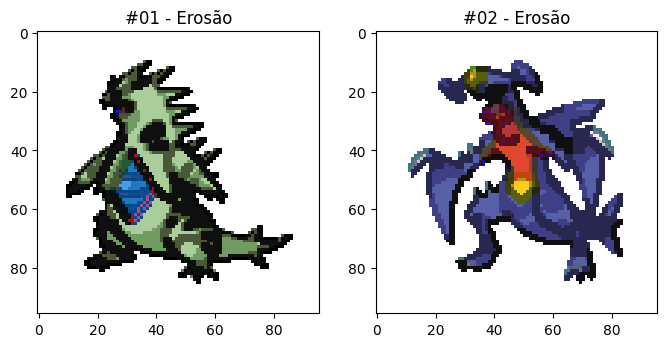

In [12]:
mask = cp.zeros((3,3,1))
mask[:,:,0] = cp.array([
    [0, 1, 0],
    [1, 1, 1],
    [0, 1, 0],
])
pk_mut1 = cp.copy(pk1)
#pk_mut1[:,:,:3] = scimg.convolve(pk1[:,:,:3], kernel)
#pk_mut1[:,:,:3] = scimg.grey_erosion(pk1[:,:,:3], size=3)
pk_mut1[:,:,:3] = scimg.grey_erosion(pk1[:,:,:3], structure=mask)
pk_mut2 = cp.copy(pk2)
pk_mut2[:,:,:3] = scimg.grey_erosion(pk2[:,:,:3], structure=mask)


figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Erosão')
axis[0].imshow(cp.asnumpy(pk_mut1), interpolation='nearest')
axis[1].set_title('#02 - Erosão')
axis[1].imshow(cp.asnumpy(pk_mut2), interpolation='nearest')

### Dilatação

In [ ]:
mask = cp.zeros((3,3,1))
mask[:,:,0] = cp.array([
    [0, 1, 0],
    [1, 1, 1],
    [0, 1, 0],
])
pk_mut1 = cp.copy(pk1)
pk_mut1[:,:,:3] = scimg.grey_dilation(pk1[:,:,:3], structure=mask)
pk_mut2 = cp.copy(pk2)
pk_mut2[:,:,:3] = scimg.grey_dilation(pk2[:,:,:3], structure=mask)


figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Dilatação')
axis[0].imshow(cp.asnumpy(pk_mut1), interpolation='nearest')
axis[1].set_title('#02 - Dilatação')
axis[1].imshow(cp.asnumpy(pk_mut2), interpolation='nearest')

### Abertura

In [ ]:
mask = cp.zeros((3,3,1))
mask[:,:,0] = cp.array([
    [0, 1, 0],
    [1, 1, 1],
    [0, 1, 0],
])
pk_mut1 = cp.copy(pk1)
pk_mut1[:,:,:3] = scimg.grey_opening(pk1[:,:,:3], structure=mask)
pk_mut2 = cp.copy(pk2)
pk_mut2[:,:,:3] = scimg.grey_opening(pk2[:,:,:3], structure=mask)


figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Abertura')
axis[0].imshow(cp.asnumpy(pk_mut1), interpolation='nearest')
axis[1].set_title('#02 - Abertura')
axis[1].imshow(cp.asnumpy(pk_mut2), interpolation='nearest')

### Fechamento

In [ ]:
mask = cp.zeros((3,3,1))
mask[:,:,0] = cp.array([
    [0, 1, 0],
    [1, 1, 1],
    [0, 1, 0],
])
pk_mut1 = cp.copy(pk1)
pk_mut1[:,:,:3] = scimg.grey_closing(pk1[:,:,:3], structure=mask)
pk_mut2 = cp.copy(pk2)
pk_mut2[:,:,:3] = scimg.grey_closing(pk2[:,:,:3], structure=mask)


figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Fechamento')
axis[0].imshow(cp.asnumpy(pk_mut1), interpolation='nearest')
axis[1].set_title('#02 - Fechamento')
axis[1].imshow(cp.asnumpy(pk_mut2), interpolation='nearest')

### Cartola Branca/Negra

In [ ]:
mask = cp.zeros((5,5,1))
mask[:,:,0] = cp.array([
    [0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0],
    [1, 1, 1, 1, 1],
    [0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0]
])
pk_mut1a = cp.copy(pk1)
pk_mut1a[:,:,:3] = scimg.black_tophat(pk1[:,:,:3], structure=mask)
pk_mut2a = cp.copy(pk2)
pk_mut2a[:,:,:3] = scimg.black_tophat(pk2[:,:,:3], structure=mask)

pk_mut1b = cp.copy(pk1)
pk_mut1b[:,:,:3] = scimg.white_tophat(pk1[:,:,:3], structure=mask)
pk_mut2b = cp.copy(pk2)
pk_mut2b[:,:,:3] = scimg.white_tophat(pk2[:,:,:3], structure=mask)


figure, axis = plt.subplots(2, 2, figsize=(8,8))
axis[0,0].set_title('#01 - Cartola Negra')
axis[0,0].imshow(cp.asnumpy(pk_mut1a), interpolation='nearest')
axis[0,1].set_title('#02 - Cartola Negra')
axis[0,1].imshow(cp.asnumpy(pk_mut2a), interpolation='nearest')
axis[1,0].set_title('#03 - Cartola Branca')
axis[1,0].imshow(cp.asnumpy(pk_mut1b), interpolation='nearest')
axis[1,1].set_title('#04 - Cartola Branca')
axis[1,1].imshow(cp.asnumpy(pk_mut2b), interpolation='nearest')

### Morfologia - Outros

In [ ]:
mask = cp.zeros((3,3,1))
mask[:,:,0] = cp.array([
    [0, 1, 0],
    [1, 1, 1],
    [0, 1, 0]
])
pk_mut1a = cp.copy(pk1)
pk_mut1a[:,:,:3] = scimg.morphological_gradient(pk1[:,:,:3], structure=mask)

pk_mut2a = cp.copy(pk2)
pk_mut2a[:,:,:3] = scimg.morphological_gradient(pk2[:,:,:3], structure=mask)

pk_mut1b = cp.copy(pk1)
pk_mut1b[:,:,:3] = scimg.morphological_laplace(pk1[:,:,:3], structure=mask)
pk_mut2b = cp.copy(pk2)
pk_mut2b[:,:,:3] = scimg.morphological_laplace(pk2[:,:,:3], structure=mask)

figure, axis = plt.subplots(2, 2, figsize=(8,8))
axis[0,0].set_title('#01 - Morf: Gradiente')
axis[0,0].imshow(cp.asnumpy(pk_mut1a), interpolation='nearest')
axis[0,1].set_title('#02 - Morf: Gradiente')
axis[0,1].imshow(cp.asnumpy(pk_mut2a), interpolation='nearest')
axis[1,0].set_title('#01 - Morf: Laplace')
axis[1,0].imshow(cp.asnumpy(pk_mut1b), interpolation='nearest')
axis[1,1].set_title('#02 - Morf: Laplace')
axis[1,1].imshow(cp.asnumpy(pk_mut2b), interpolation='nearest')

## Outros
### Shuffle

In [ ]:

pk_mut1 = cp.copy(pk1)
pk_mut2 = cp.copy(pk2)
cp.random.shuffle(pk_mut1)
cp.random.shuffle(pk_mut2)

figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Embaralhar')
axis[0].imshow(cp.asnumpy(pk_mut1), interpolation='nearest')
axis[1].set_title('#02 - Embaralhar')
axis[1].imshow(cp.asnumpy(pk_mut2), interpolation='nearest')


### Inverter

In [ ]:
pk_mut1 = cp.copy(pk1)
pk_mut2 = cp.copy(pk2)

mk1 = pk1[:,:,3] != 255
mk2 = pk2[:,:,3] != 255
pk_mut1[:,:,:3] = cp.bitwise_not(pk1[:,:,:3])
pk_mut2[:,:,:3] = cp.bitwise_not(pk2[:,:,:3])

figure, axis = plt.subplots(1, 2, figsize=(8, 8))
axis[0].set_title('#01 - Inverter')
axis[0].imshow(cp.asnumpy(pk_mut1), interpolation='nearest')
axis[1].set_title('#02 - Inverter')
axis[1].imshow(cp.asnumpy(pk_mut2), interpolation='nearest')


### Dithering

In [ ]:
def resizesize(img):
    return scimg.zoom(img, [2,2,1], mode='nearest', prefilter=False, order=0)
def smolsize(img):
    return scimg.zoom(img, [0.5,0.5,1], mode='nearest', prefilter=False, order=0)

def bayer_dithering_RGB(img):
    bayer = cp.zeros_like(img)
    #(bb,gg,rr,alpha) = cv2.split(sm_img)
    #(bb,gg,rr,alpha) = cp.split(img)
    bb = img[:,:,0]
    gg = img[:,:,1]/1.5
    rr = img[:,:,2]
    alpha = img[:,:,3]

    bayer[1::2,0::2,2] = rr[1::2,0::2]
    bayer[0::2,0::2,1] = gg[0::2,0::2] 
    bayer[1::2,1::2,1] = gg[1::2,1::2] 
    bayer[0::2,1::2,0] = bb[0::2,1::2]
    
    bayer[:,:,3] = alpha[:,:]
    
    #bayer = resize_by_factor(bayer, 2)

    return bayer

def bayer_dithering_BY(img):
    #sm_img = resize_by_factor(img, 0.5)
    bayer = cp.zeros_like(img)
    
    #(bb,gg,rr,alpha) = cv2.split(sm_img)
    #(bb,gg,rr,alpha) = cp.split(sm_img)
    bb = img[:,:,0]
    gg = img[:,:,1]
    rr = img[:,:,2]
    alpha = img[:,:,3]
    
    bayer[1::2,0::2,0] = bb[1::2,0::2]
    
    bayer[0::2,0::2,1] = gg[0::2,0::2]
    bayer[0::2,0::2,2] = rr[0::2,0::2]
    bayer[1::2,1::2,1] = gg[1::2,1::2]
    bayer[1::2,1::2,2] = rr[1::2,1::2]

    bayer[0::2,1::2,0] = bb[0::2,1::2]
    
    bayer[:,:,3] = alpha[:,:]
    
    #bayer = resize_by_factor(bayer, 2)
    return resizesize(bayer)
    #return bayer

pk_mut1a = bayer_dithering_RGB(pk1)
pk_mut2a = bayer_dithering_RGB(pk2)
pk_mut1b = bayer_dithering_BY(pk1)
pk_mut2b = bayer_dithering_BY(pk2)

figure, axis = plt.subplots(2, 2, figsize=(8, 8))
axis[0,0].set_title('#01 - Dithering (RGB)')
axis[0,0].imshow(cp.asnumpy(pk_mut1a), interpolation='nearest')
axis[0,1].set_title('#02 - Dithering (RGB)')
axis[0,1].imshow(cp.asnumpy(pk_mut2a), interpolation='nearest')
axis[1,0].set_title('#03 - Dithering (BY)')
axis[1,0].imshow(cp.asnumpy(pk_mut1b), interpolation='nearest')
axis[1,1].set_title('#04 - Dithering (BY)')
axis[1,1].imshow(cp.asnumpy(pk_mut2b), interpolation='nearest')


In [ ]:
def mutate(self, pk_img):
        
        mutation_type = randint(0, 10)
        #print(f'Tipo de mutação:{mutation_type}')
        match mutation_type:
            #case 12:
                #pk_img = utils.fit_img(pk_img)
            #case 28:
                ####gauss = scimg.gaussian_filter(pk_img, sigma=2)
                #gauss = cv2.GaussianBlur(np.copy(pk_img), (3,3),0)
                #mk = gauss[:,:,3] > 0
                #pk_img = cv2.addWeighted(pk_img, 2.0, gauss, -1.0, 0)
                #pk_img[mk,3] = 255
            #case 29:
                #pk_img = self.visible_mono(pk_img)
        
        #if randint(0,9) == 9:
        #    pk_img = self.mutate(pk_img=pk_img)
        
        return pk_img